In [1]:
import os
import numpy as np
import pandas as  pd  
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras.layers  import Dense  , Flatten , Conv2D , MaxPool2D 
from tensorflow.keras import layers 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.applications.vgg16 import VGG16 , preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay )


In [ ]:
DATA_DIR = "PetImages"
os.listdir(DATA_DIR)

['Dog', 'Cat']

In [3]:
os.listdir(DATA_DIR)

['Dog', 'Cat']

In [4]:
dog_data = os.listdir(os.path.join(DATA_DIR , os.listdir(DATA_DIR)[0]))

In [5]:
dog_data[0]

'7981.jpg'

In [6]:
dog_folder_path = os.path.join(DATA_DIR , os.listdir(DATA_DIR)[0])

In [7]:
imgp = os.path.join(dog_folder_path ,dog_data[0])
imgp

'/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/Dog/7981.jpg'

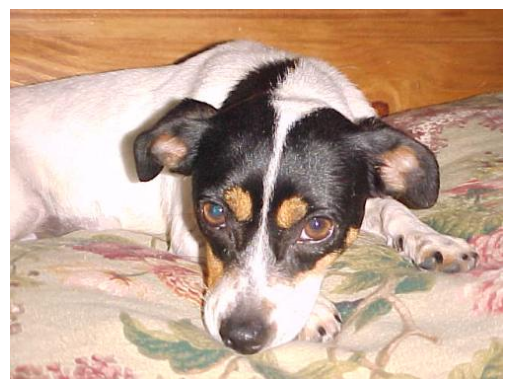

In [8]:
img = plt.imread(imgp)
plt.imshow(img)
plt.axis('off')
plt.show()

In [9]:
image = []
label = []

for folder in os.listdir(DATA_DIR) :
    for file in os.listdir(os.path.join(DATA_DIR ,folder)) :
        folder_path = os.path.join(DATA_DIR ,folder)
        file_path = os.path.join(folder_path ,file)
        image.append(file_path)
        label.append(folder)

df = pd.DataFrame({
    "image" : image  , 
    "label" : label
})

df 

,image,label
0,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Dog
1,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Dog
2,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Dog
3,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Dog
4,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Dog
...,...,...
24993,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Cat
24994,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Cat
24995,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Cat
24996,/kaggle/input/datasets/bhavikjikadara/dog-and-...,Cat


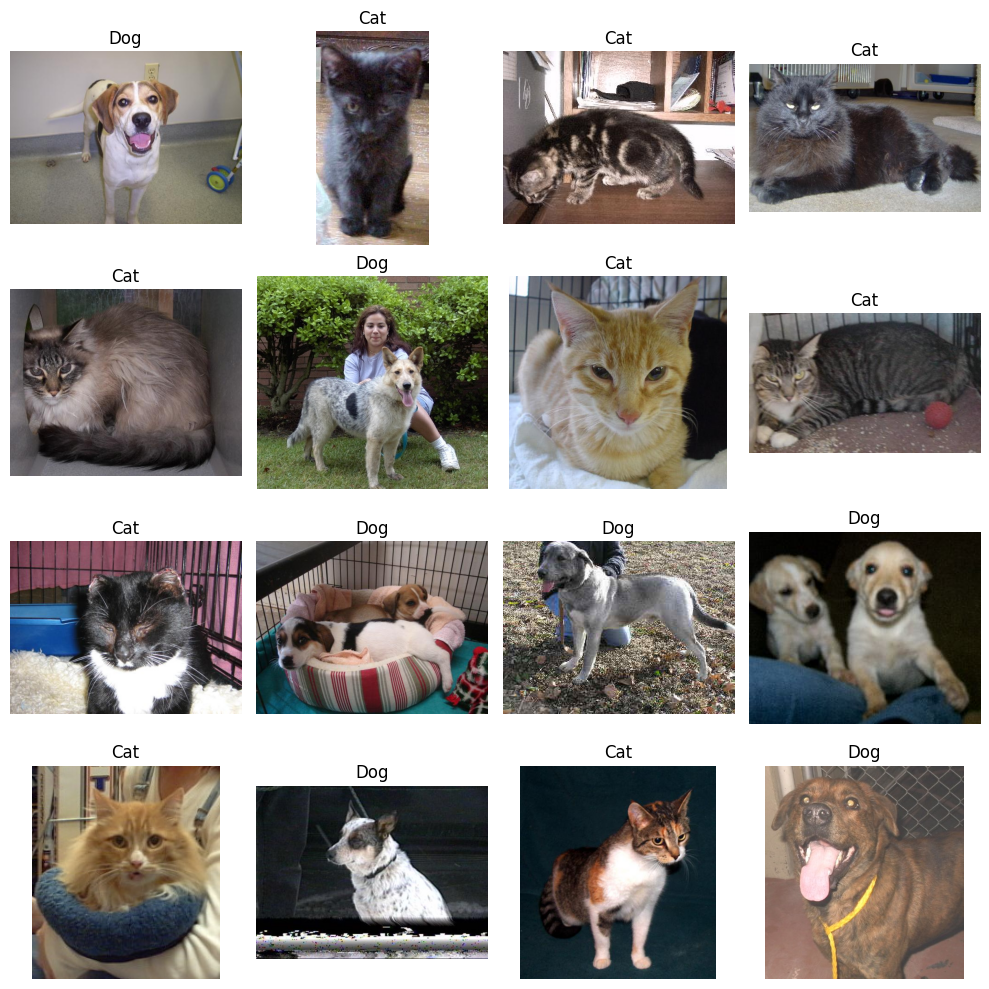

In [10]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    randomn = np.random.randint(df.shape[0])   # random row index
    img = plt.imread(df["image"].iloc[randomn])  # <-- use randomn + iloc
    label = df["label"].iloc[randomn]            # <-- same row for label
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

<Axes: xlabel='label'>

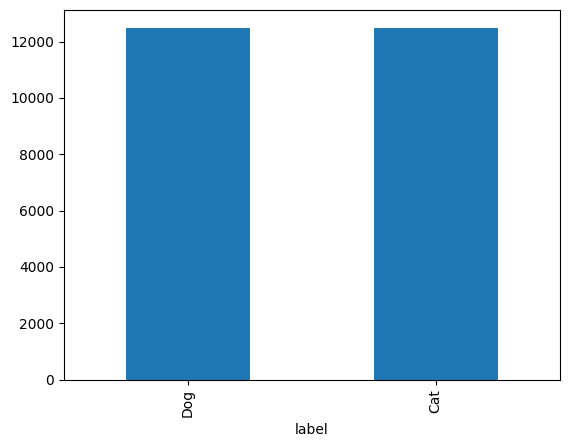

In [11]:
df['label'].value_counts().plot(kind='bar')

In [12]:
from PIL import Image
sizes = df['image'].sample(100).apply(lambda p: Image.open(p).size)
print(sizes.value_counts())

image
(500, 375)    25
(500, 333)     3
(320, 240)     2
(348, 500)     2
(500, 369)     2
              ..
(381, 500)     1
(173, 261)     1
(354, 388)     1
(250, 232)     1
(500, 386)     1
Name: count, Length: 69, dtype: int64


In [13]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, stratify=train_df['label'], random_state=42)

print(len(train_df), len(val_df), len(test_df))

17998 2000 5000


In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(rescale=1./255)   
test_datagen = ImageDataGenerator(rescale=1./255)  

In [15]:
IMG_SIZE = (224, 224)  
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image',          
    y_col='label',           
    target_size=IMG_SIZE,    
    batch_size=BATCH_SIZE,
    class_mode='categorical',  
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,          
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 17998 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [16]:
print(train_generator.class_indices)

{'Cat': 0, 'Dog': 1}


In [17]:
train_df['label'] = train_df['label'].astype(str)
val_df['label']   = val_df['label'].astype(str)
test_df['label']  = test_df['label'].astype(str)

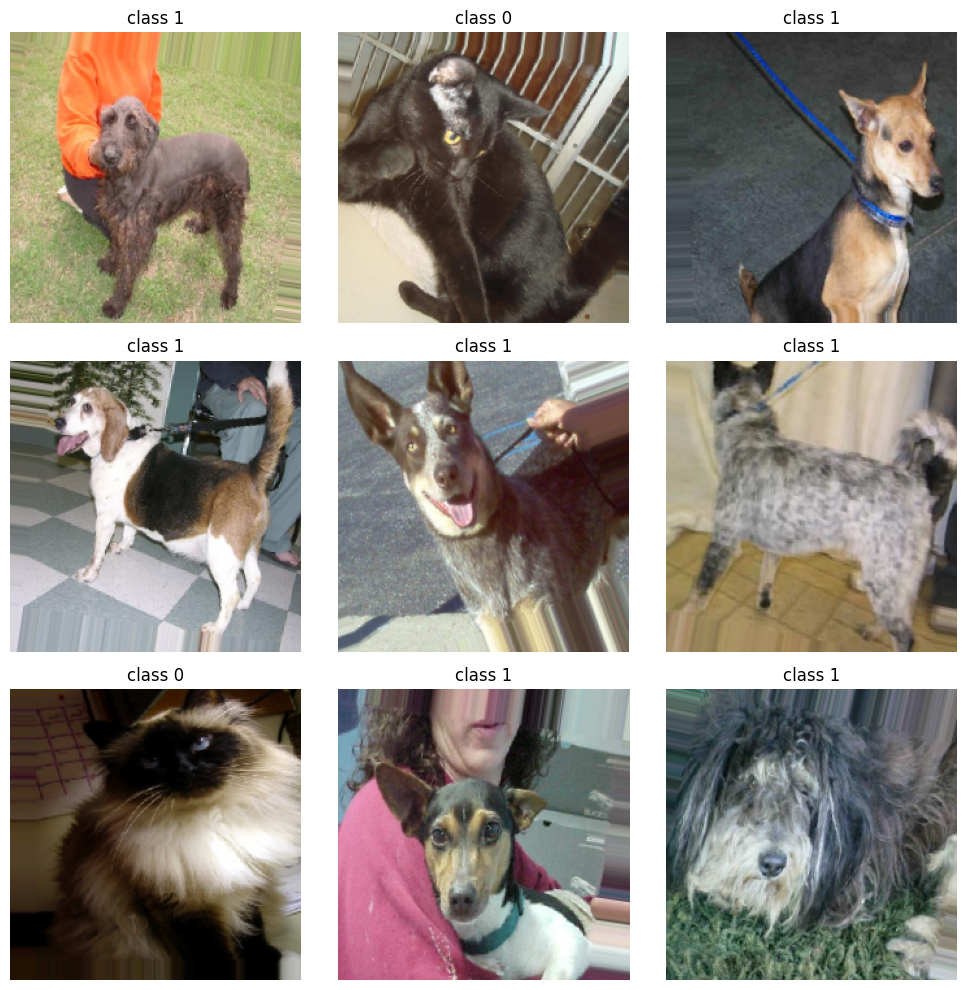

In [18]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(f"class {labels[i].argmax()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [22]:
IMG_SIZE = (224, 224, 3)
num_classes = 2

model = Sequential([
    layers.Input(shape=IMG_SIZE),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
EPOCHS = 15   
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 325s 578ms/step - accuracy: 0.5823 - loss: 0.6656 - val_accuracy: 0.6085 - val_loss: 0.6494
Epoch 2/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 265s 470ms/step - accuracy: 0.6256 - loss: 0.6388 - val_accuracy: 0.6420 - val_loss: 0.6231
Epoch 3/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 256s 454ms/step - accuracy: 0.6739 - loss: 0.5992 - val_accuracy: 0.7125 - val_loss: 0.5662
Epoch 4/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 253s 449ms/step - accuracy: 0.7047 - loss: 0.5707 - val_accuracy: 0.7090 - val_loss: 0.5752
Epoch 5/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 255s 452ms/step - accuracy: 0.7192 - loss: 0.5502 - val_accuracy: 0.7530 - val_loss: 0.5126
Epoch 6/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 258s 457ms/step - accuracy: 0.7303 - loss: 0.5399 - val_accuracy: 0.7645 - val_loss: 0.5074
Epoch 7/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 255s 452ms/step - accuracy: 0.7425 - loss: 0.5226 - val_accuracy: 0.7500 - val_loss: 0.5046
Epoch 8/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 254s 451ms/step - accuracy: 0.7515 -

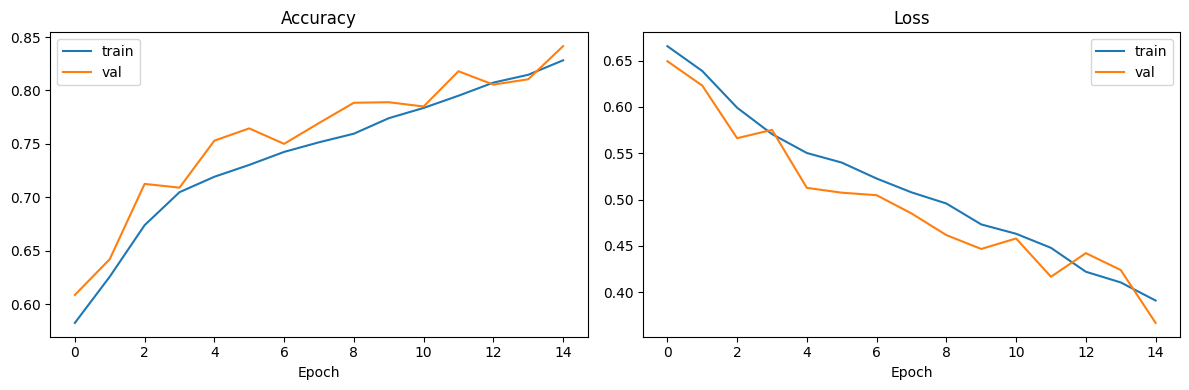

In [26]:
import matplotlib.pyplot as plt
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax[0].plot(history.history['accuracy'],     label='train')
    ax[0].plot(history.history['val_accuracy'], label='val')
    ax[0].set_title('Accuracy')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()

    # Loss
    ax[1].plot(history.history['loss'],     label='train')
    ax[1].plot(history.history['val_loss'], label='val')
    ax[1].set_title('Loss')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [27]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
num_classes = 2

train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,  
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
)

val_datagen_vgg  = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen_vgg = train_datagen_vgg.flow_from_dataframe(
    dataframe=train_df,
    x_col='image', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)

val_gen_vgg = val_datagen_vgg.flow_from_dataframe(
    dataframe=val_df,
    x_col='image', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_gen_vgg = test_datagen_vgg.flow_from_dataframe(
    dataframe=test_df,
    x_col='image', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print(train_gen_vgg.class_indices)

Found 17998 validated image filenames belonging to 2 classes.
Found 2000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.
{'Cat': 0, 'Dog': 1}


In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

base_model = VGG16(
    weights='imagenet',
    include_top=False,          
    input_shape=(224, 224, 3)
)
base_model.trainable = False  

vgg_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),        
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,554 (56.64 MB)

 Trainable params: 132,354 (517.01 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [29]:
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 310s 515ms/step - accuracy: 0.9614 - loss: 0.1104 - val_accuracy: 0.9840 - val_loss: 0.0602
Epoch 2/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 276s 491ms/step - accuracy: 0.9753 - loss: 0.0679 - val_accuracy: 0.9830 - val_loss: 0.0572
Epoch 3/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 274s 487ms/step - accuracy: 0.9764 - loss: 0.0654 - val_accuracy: 0.9830 - val_loss: 0.0581
Epoch 4/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 281s 498ms/step - accuracy: 0.9761 - loss: 0.0634 - val_accuracy: 0.9845 - val_loss: 0.0487
Epoch 5/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 278s 493ms/step - accuracy: 0.9801 - loss: 0.0570 - val_accuracy: 0.9845 - val_loss: 0.0415
Epoch 6/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 266s 473ms/step - accuracy: 0.9796 - loss: 0.0579 - val_accuracy: 0.9880 - val_loss: 0.0380
Epoch 7/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 274s 487ms/step - accuracy: 0.9814 - loss: 0.0526 - val_accuracy: 0.9840 - val_loss: 0.0397
Epoch 8/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 269s 477ms/step - accuracy: 0.9814 -

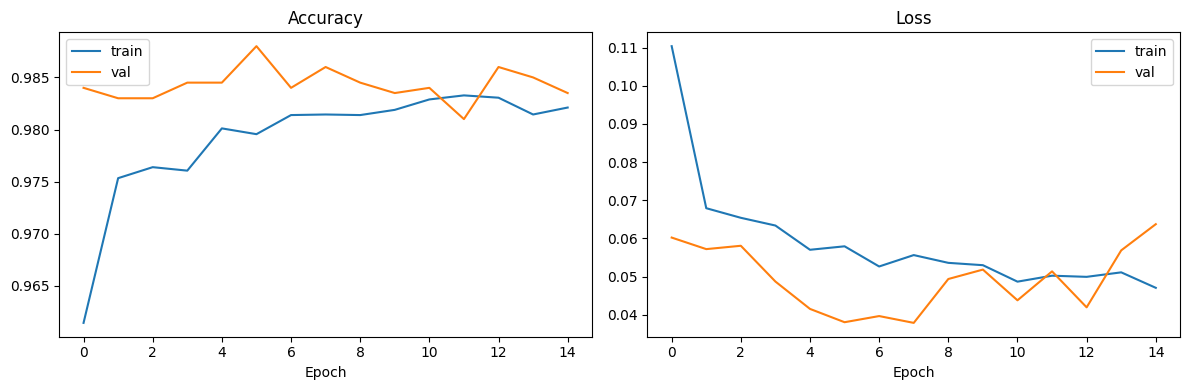

In [30]:
history_vgg_1 = vgg_model.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=15,                
    verbose=1
)

plot_history(history_vgg_1)

In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("cat_dog_model_cnn.tflite", "wb") as f:
    f.write(tflite_model)

converter = tf.lite.TFLiteConverter.from_keras_model(vgg_model)
tflite_model = converter.convert()
with open("cat_dog_model_vgg.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmp94415fp9/assets


INFO:tensorflow:Assets written to: /tmp/tmp94415fp9/assets


Saved artifact at '/tmp/tmp94415fp9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135688089141520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688089149968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688089142288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688154283664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688154276560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688154278096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688154275984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688154278672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688154277904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688154277328: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1789679096.322568      59 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789679096.322637      59 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789679096.330223      59 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


INFO:tensorflow:Assets written to: /tmp/tmpblgv0l2o/assets


INFO:tensorflow:Assets written to: /tmp/tmpblgv0l2o/assets


Saved artifact at '/tmp/tmpblgv0l2o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_56')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135688154283280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135687763375504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135687763376272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135687763376080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135687763376464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688015471504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688015468624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688015472464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688015467664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135688015470160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13568801547

W0000 00:00:1789679098.182378      59 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789679098.182434      59 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
